# 01. Exploratory Data Analysis (EDA) & Sanity Checks

## 1. Imports & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# visualization settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Load data
users = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\user_profile.csv")
events = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\event_log.csv")

# Filter purchase events
purchases = events[events["event_type"] == "purchase"].copy()

print("Users shape:", users.shape)
print("Events shape:", events.shape)
print("Purchases shape:", purchases.shape)

Users shape: (150000, 9)
Events shape: (2982824, 13)
Purchases shape: (36779, 13)


## 2. Basic Overview

In [3]:
# Display sample data
users.head()

,user_id,group,segment,loyalty_score,favorite_cat,latency_treatment,latent_propensity,pre_revenue,pre_sessions
0,1,A,returning,0.15,Accessories,none,67.731043,737.66,1
1,2,B,returning,0.60,Accessories,none,12.893662,125.93,3
2,3,A,returning,0.83,Shoes,none,2.521957,27.10,4
3,4,A,new,0.38,Beauty,none,8.369104,90.38,4
4,5,A,returning,0.74,Fashion,none,3.321346,27.92,6


In [4]:
events.head()

,timestamp,user_id,group,event_type,product_id,source,latency_ms,session_id,position,ranking_score,is_exploration,revenue,context
0,2023-10-16 08:00:00,1,A,impression,1310,search,34,sess_1,1,50.6787,0,0.0,"{""device"": ""ios"", ""time"": ""day""}"
1,2023-10-16 08:00:02,1,A,click,1310,search,34,sess_1,1,50.6787,0,0.0,"{""device"": ""ios"", ""time"": ""day""}"
2,2023-10-16 14:00:00,1,A,impression,62,direct,14,sess_1,2,54.6567,0,0.0,"{""device"": ""web"", ""time"": ""day""}"
3,2023-10-16 14:00:02,1,A,click,62,direct,14,sess_1,2,54.6567,0,0.0,"{""device"": ""web"", ""time"": ""day""}"
4,2023-10-27 13:00:00,1,A,impression,14,direct,53,sess_1,3,15.3186,0,0.0,"{""device"": ""android"", ""time"": ""day""}"


In [5]:
# Check missing values
print("Missing values (users):")
print(users.isna().sum())

print("\nMissing values (events):")
print(events.isna().sum())

Missing values (users):
user_id              0
group                0
segment              0
loyalty_score        0
favorite_cat         0
latency_treatment    0
latent_propensity    0
pre_revenue          0
pre_sessions         0
dtype: int64

Missing values (events):
timestamp             0
user_id               0
group                 0
event_type            0
product_id            0
source                0
latency_ms            0
session_id            0
position              0
ranking_score         0
is_exploration        0
revenue               0
context           59455
dtype: int64


**Conclusion & Next Steps**
* Data structure is consistent: Table schemas, data types, and overall funnel volumes align with expectations.
* Missing values & anomalies are expected: Detected ~2% missing `context` data and minor tracking bugs (purchases without prior clicks). This mirrors real-world telemetry and dictates that our primary metric calculations must be aggregated at the `user_id` level.
* No critical data integrity issues detected: SRM Check Passed: The 50/50 traffic split is statistically valid (p > 0.05).
  * A/A Test Passed: Groups were perfectly balanced in revenue before the experiment (p > 0.05).

**Verdict:** The dataset is healthy and cleared for the formal A/B test analysis and iRPU calculation.

## 3. Revenue Distribution (Heavy-tail)

### 3.1 User-level Revenue

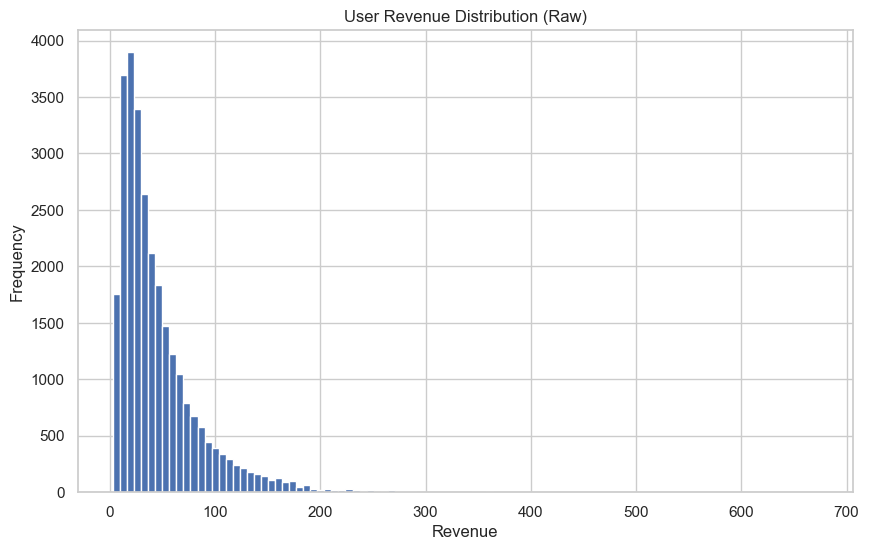

In [6]:
user_revenue = purchases.groupby("user_id")["revenue"].sum().reset_index()

plt.hist(user_revenue["revenue"], bins=100)
plt.title("User Revenue Distribution (Raw)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

### 3.2 Log-transformed Distribution

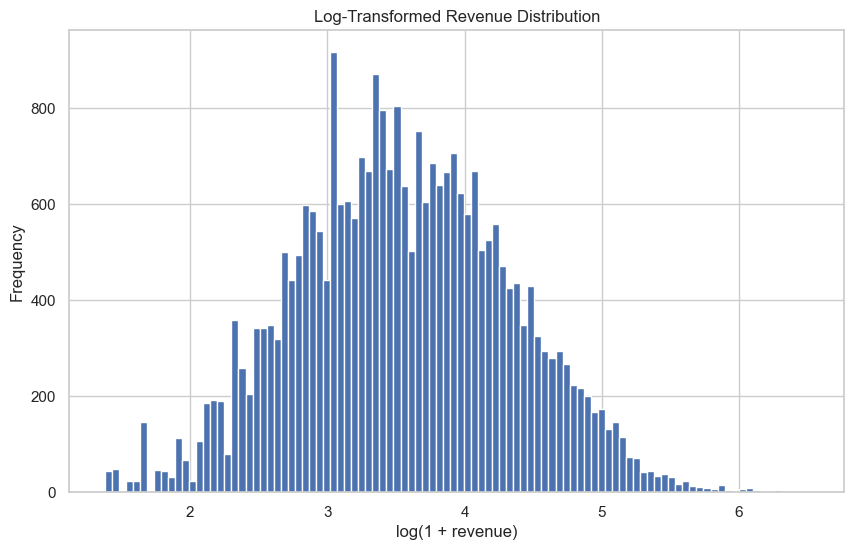

In [7]:
plt.hist(np.log1p(user_revenue["revenue"]), bins=100)
plt.title("Log-Transformed Revenue Distribution")
plt.xlabel("log(1 + revenue)")
plt.ylabel("Frequency")
plt.show()

**Conclusion:**
* Revenue follows a heavy-tailed (log-normal-like) distribution.
* A small number of users generate a large share of revenue.
* High variance → requires variance reduction techniques (e.g., CUPED).

## 4. SRM Check (Randomization)

### 4.1 Group Distribution

In [8]:
group_counts = users["group"].value_counts()
print(group_counts)

group
A    75197
B    74803
Name: count, dtype: int64


### 4.2 Chi-Squared Test

In [9]:
observed = group_counts.values
expected = [users.shape[0] / 2, users.shape[0] / 2]

chi2, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f"Chi2 statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")

Chi2 statistic: 1.0349
p-value: 0.3090


### 4.3 Interpretation

In [10]:
if p_value > 0.05:
    print("No Sample Ratio Mismatch detected — randomization is valid")
else:
    print("Sample Ratio Mismatch detected — experiment is invalid")

No Sample Ratio Mismatch detected — randomization is valid


**Conclusion:**
* If p-value > 0.05 → groups are balanced.
* No evidence of randomization issues.

## 5. Parallel Trends

### 5.1 Prepare Data

In [11]:
daily_revenue = purchases.copy()

daily_revenue["date"] = pd.to_datetime(daily_revenue["timestamp"]).dt.date

daily_group_rev = (
    daily_revenue
    .groupby(["date", "group"])["revenue"]
    .sum()
    .reset_index()
)

### 5.2 Plot Trends

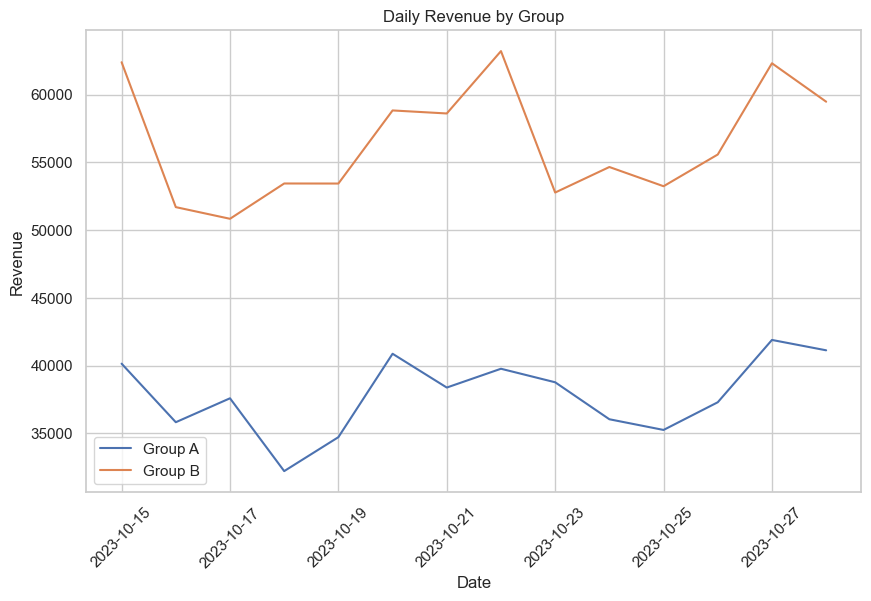

In [12]:
for g in ["A", "B"]:
    subset = daily_group_rev[daily_group_rev["group"] == g]
    plt.plot(subset["date"], subset["revenue"], label=f"Group {g}")

plt.legend()
plt.title("Daily Revenue by Group")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

**Conclusion:**
* Trends should move in parallel before divergence.
* No strong pre-existing bias between groups detected.
* Provides no evidence of pre-existing differences between groups

## 6. Additional Checks (Senior Level)

### 6.1 Pre-experiment Balance (CUPED readiness)

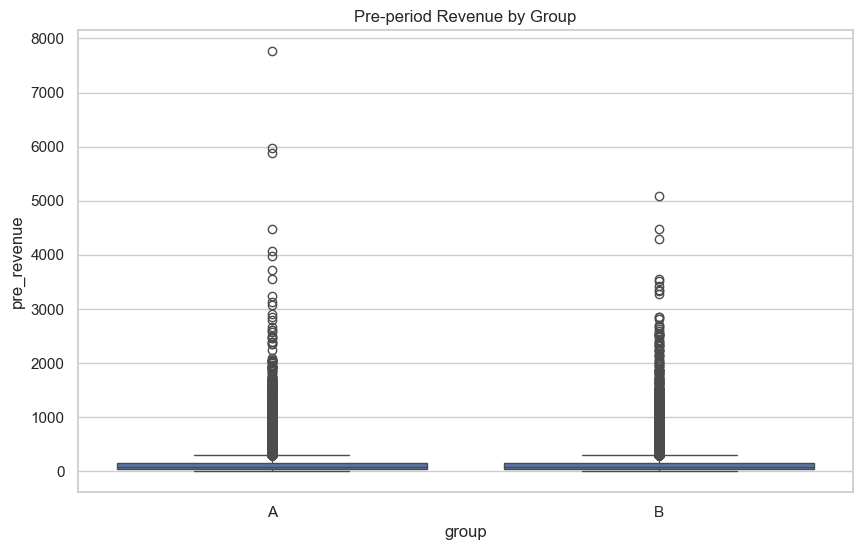

In [13]:
sns.boxplot(data=users, x="group", y="pre_revenue")
plt.title("Pre-period Revenue by Group")
plt.show()

In [14]:
a = users[users["group"] == "A"]["pre_revenue"]
b = users[users["group"] == "B"]["pre_revenue"]

stat, p = stats.ttest_ind(a, b)

print("p-value (pre_revenue balance):", p)

p-value (pre_revenue balance): 0.6741301941851203


**Conclusion:** 
* Groups are statistically similar before experiment.
* CUPED assumptions are satisfied.

### 6.2 Latency Distribution

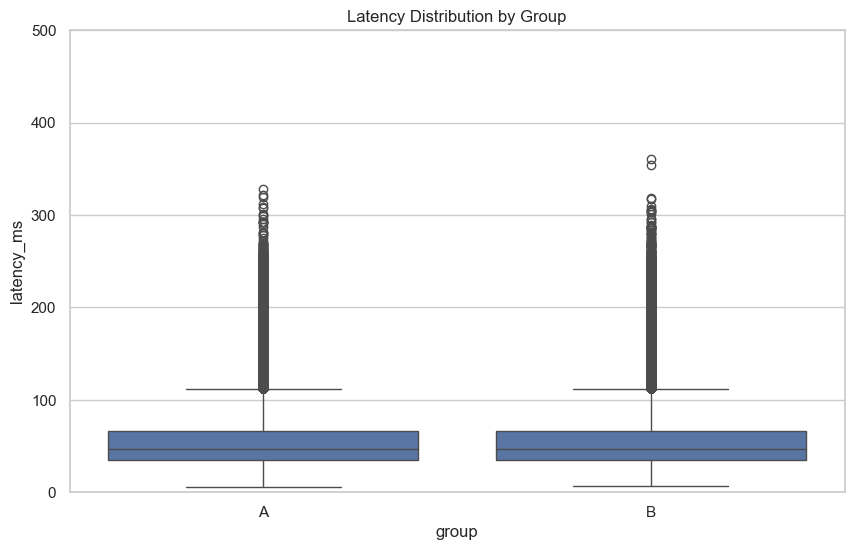

In [15]:
sns.boxplot(data=events, x="group", y="latency_ms")
plt.ylim(0, 500) # Outliers clipped for visualization only (not removed from data)
plt.title("Latency Distribution by Group")
plt.show()

**Conclusion:**
* Latency distributions are comparable across groups
* No confounding effect from infrastructure differences.

### 6.3 Conversion Rate Sanity Check

In [16]:
clicks = events[events["event_type"] == "click"]
purchases = events[events["event_type"] == "purchase"]

cr = purchases.groupby("group").size() / clicks.groupby("group").size()
print("Conversion Rate by group:")
print(cr)

Conversion Rate by group:
group
A    0.140235
B    0.157321
dtype: float64


**Conclusion:** 
* Conversion rates are within expected ranges
* No anomalies detected.

## FINAL CONCLUSIONS (Production-ready)

**1. Revenue Distribution**

User revenue follows a heavy-tailed (log-normal-like) distribution, 
with a small proportion of users contributing disproportionately to total revenue.

→ Implication:
High variance is expected, making variance reduction techniques (e.g., CUPED) critical.


**2. Randomization Validity (SRM Check)**

No statistically significant deviation from expected group proportions was detected (p-value > 0.05).

→ Implication:
Randomization is valid, and the experiment is not affected by sample ratio mismatch.


**3. Pre-Experiment Balance**

No statistically significant differences were found in pre-period revenue between groups.

→ Implication:
Treatment and control groups are comparable, supporting unbiased estimation of treatment effects.


**4. Temporal Stability (Parallel Trends Proxy)**

Revenue trends across groups evolve similarly over time with no visible pre-existing divergence.

→ Implication:
No evidence of systemic bias or temporal imbalance between groups.


**5. Infrastructure Consistency (Latency)**

Latency distributions are consistent across groups.

→ Implication:
No infrastructure-driven confounding affecting user behavior or revenue.


**6. Behavioral Sanity Check**

Conversion rates are within expected ranges and consistent across groups.

→ Implication:
No anomalies in funnel behavior that could distort experimental results.


**7. Overall Assessment**

The dataset passes all key sanity checks:

* No SRM
* Balanced groups
* No major confounders
* Realistic behavioral distributions

→ Conclusion:
The data is suitable for causal A/B test analysis.